# Сравнение метаэвристических алгоритмов CSOA и DROA с PSO

В задании нужно выбрать два метода из CSOA, DROA и TROA, сравнить их на одной функции и добавить уже реализованный PSO как базовый алгоритм. Здесь выбраны CSOA и DROA: у них разная логика движения популяции, поэтому сравнение получается не формальным.

Все параметры и сама функция вынесены в отдельные ячейки ниже. Для повторения опыта достаточно выполнить ноутбук сверху вниз.

In [1]:
import os
import tempfile
from pathlib import Path

TASK_DIR_NAME = "Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)"


def find_task_dir(name: str) -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for base in candidates:
        if base.name == name:
            return base
        nested = base / name
        if nested.exists():
            return nested.resolve()
    raise RuntimeError(f"Не удалось найти папку задания {name!r}")


TASK_DIR = find_task_dir(TASK_DIR_NAME)
GRAPHS_DIR = TASK_DIR / "graphs"
BUILD_DIR = TASK_DIR / "build"
GRAPHS_DIR.mkdir(exist_ok=True)
BUILD_DIR.mkdir(exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mpl-cache-"))

print(TASK_DIR)

/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)


In [2]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.grid": True,
})

Matplotlib is building the font cache; this may take a moment.


## Функция для оптимизации

По умолчанию используется двумерная функция Экли. Она удобна для проверки метаэвристик: минимум известен, область ограничена, а рельеф не сводится к одной простой параболе.

Чтобы проверить другую функцию, достаточно заменить `objective`, `BOUNDS`, `OBJECTIVE_NAME` и, если минимум известен, `GLOBAL_MINIMUM`.

In [3]:
OBJECTIVE_NAME = "Функция Экли"
BOUNDS = np.array([[-5.0, 5.0], [-5.0, 5.0]], dtype=float)
GLOBAL_MINIMUM = {
    "point": np.array([0.0, 0.0]),
    "value": 0.0,
}


def objective(x):
    x = np.asarray(x, dtype=float)
    n = x.shape[-1]
    quadratic = np.sum(x * x, axis=-1)
    cosine = np.sum(np.cos(2 * np.pi * x), axis=-1)
    return -20 * np.exp(-0.2 * np.sqrt(quadratic / n)) - np.exp(cosine / n) + 20 + np.e


def evaluate_population(points: np.ndarray) -> np.ndarray:
    return np.asarray(objective(points), dtype=float)

## Общие вспомогательные функции

Все методы ниже работают с одинаковыми границами. Если частица или агент выходит за область, координаты отражаются обратно внутрь допустимого прямоугольника. Это мягче обычного `clip`: направление поиска частично сохраняется.

In [4]:
def reflect_bounds(points: np.ndarray, bounds: np.ndarray = BOUNDS) -> np.ndarray:
    arr = np.asarray(points, dtype=float)
    one_dimensional = arr.ndim == 1
    reflected = arr.reshape(1, -1).copy() if one_dimensional else arr.copy()

    for j, (lo, hi) in enumerate(bounds):
        width = hi - lo
        reflected[:, j] = lo + np.mod(reflected[:, j] - lo, 2 * width)
        over = reflected[:, j] > hi
        reflected[over, j] = hi - (reflected[over, j] - hi)

    reflected = np.clip(reflected, bounds[:, 0], bounds[:, 1])
    return reflected[0] if one_dimensional else reflected


def initial_population(rng: np.random.Generator, population_size: int) -> np.ndarray:
    return rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(population_size, len(BOUNDS)))


def best_from_values(positions: np.ndarray, values: np.ndarray):
    index = int(np.argmin(values))
    return positions[index].copy(), float(values[index]), index

## Параметры методов

Все параметры можно менять здесь. Для честного сравнения число агентов и число итераций одинаковые.

In [5]:
COMMON = {
    "population_size": 45,
    "iterations": 160,
}

PSO_PARAMS = {
    "seed": 2026,
    "inertia_start": 0.75,
    "inertia_end": 0.30,
    "cognitive": 1.55,
    "social": 1.65,
    "max_velocity_fraction": 0.25,
}

CSOA_PARAMS = {
    "seed": 2027,
    "seeking_memory_pool": 5,
    "seeking_range": 0.22,
    "changed_dimensions_share": 0.80,
    "tracing_ratio": 0.22,
    "tracing_acceleration": 2.05,
    "max_velocity_fraction": 0.25,
}

DROA_PARAMS = {
    "seed": 2028,
    "radius_start": 0.08,
    "radius_end": 0.65,
    "inertia_start": 0.85,
    "inertia_end": 0.30,
    "separation_start": 0.08,
    "separation_end": 0.20,
    "alignment": 0.12,
    "cohesion": 0.12,
    "food_start": 1.20,
    "food_end": 2.00,
    "enemy_start": 0.15,
    "max_step_fraction": 0.18,
}

## PSO: метод роя частиц

PSO используется здесь как базовый алгоритм для сравнения. Каждая частица хранит собственную лучшую точку и движется к ней и к лучшей точке всего роя.

In [6]:
def run_pso(params=PSO_PARAMS, common=COMMON):
    rng = np.random.default_rng(params["seed"])
    population_size = common["population_size"]
    iterations = common["iterations"]
    dimension = len(BOUNDS)
    span = BOUNDS[:, 1] - BOUNDS[:, 0]

    positions = initial_population(rng, population_size)
    velocities = rng.uniform(-0.15 * span, 0.15 * span, size=(population_size, dimension))
    values = evaluate_population(positions)

    personal_best_positions = positions.copy()
    personal_best_values = values.copy()
    global_best_position, global_best_value, _ = best_from_values(positions, values)

    best_history = [global_best_value]
    best_position_history = [global_best_position.copy()]
    positions_history = [positions.copy()]

    max_velocity = params["max_velocity_fraction"] * span
    for iteration in range(iterations):
        progress = iteration / max(1, iterations - 1)
        inertia = (1 - progress) * params["inertia_start"] + progress * params["inertia_end"]

        r1 = rng.random(size=(population_size, dimension))
        r2 = rng.random(size=(population_size, dimension))
        velocities = (
            inertia * velocities
            + params["cognitive"] * r1 * (personal_best_positions - positions)
            + params["social"] * r2 * (global_best_position - positions)
        )
        velocities = np.clip(velocities, -max_velocity, max_velocity)
        positions = reflect_bounds(positions + velocities)

        values = evaluate_population(positions)
        improved = values < personal_best_values
        personal_best_positions[improved] = positions[improved]
        personal_best_values[improved] = values[improved]

        candidate_position, candidate_value, _ = best_from_values(
            personal_best_positions, personal_best_values
        )
        if candidate_value < global_best_value:
            global_best_position = candidate_position
            global_best_value = candidate_value

        best_history.append(global_best_value)
        best_position_history.append(global_best_position.copy())
        positions_history.append(positions.copy())

    return {
        "method": "PSO",
        "best_position": global_best_position,
        "best_value": global_best_value,
        "best_history": np.array(best_history),
        "best_position_history": np.array(best_position_history),
        "positions_history": np.array(positions_history),
        "final_positions": positions,
    }

## CSOA: Cat Swarm Optimization

В CSOA есть два режима. В режиме поиска агент пробует несколько близких кандидатов и выбирает один из них с вероятностью, зависящей от значения функции. В режиме преследования агент меняет скорость в направлении лучшей найденной точки.

In [7]:
def run_csoa(params=CSOA_PARAMS, common=COMMON):
    rng = np.random.default_rng(params["seed"])
    population_size = common["population_size"]
    iterations = common["iterations"]
    dimension = len(BOUNDS)
    span = BOUNDS[:, 1] - BOUNDS[:, 0]

    positions = initial_population(rng, population_size)
    velocities = np.zeros_like(positions)
    values = evaluate_population(positions)
    global_best_position, global_best_value, _ = best_from_values(positions, values)

    best_history = [global_best_value]
    best_position_history = [global_best_position.copy()]
    positions_history = [positions.copy()]

    max_velocity = params["max_velocity_fraction"] * span
    seeking_pool = params["seeking_memory_pool"]
    changed_dimensions = max(1, int(np.ceil(params["changed_dimensions_share"] * dimension)))

    for _ in range(iterations):
        tracing_count = max(1, int(params["tracing_ratio"] * population_size))
        tracing_indices = set(rng.choice(population_size, tracing_count, replace=False))

        for i in range(population_size):
            if i in tracing_indices:
                velocities[i] = (
                    velocities[i]
                    + params["tracing_acceleration"] * rng.random(dimension) * (global_best_position - positions[i])
                )
                velocities[i] = np.clip(velocities[i], -max_velocity, max_velocity)
                candidate = reflect_bounds(positions[i] + velocities[i])
                candidate_value = float(objective(candidate))

                if candidate_value <= values[i] or rng.random() < 0.05:
                    positions[i] = candidate
                    values[i] = candidate_value
            else:
                candidates = [positions[i].copy()]
                for _ in range(seeking_pool - 1):
                    candidate = positions[i].copy()
                    dims = rng.choice(dimension, changed_dimensions, replace=False)
                    direction = rng.choice([-1.0, 1.0], size=len(dims))
                    scale = np.maximum(np.abs(candidate[dims]), 0.1 * span[dims])
                    candidate[dims] += direction * params["seeking_range"] * scale * rng.random(len(dims))
                    candidates.append(reflect_bounds(candidate))

                candidate_positions = np.vstack(candidates)
                candidate_values = evaluate_population(candidate_positions)
                weights = candidate_values.max() - candidate_values
                if np.allclose(weights.sum(), 0.0):
                    probabilities = np.full(len(candidate_positions), 1 / len(candidate_positions))
                else:
                    probabilities = weights / weights.sum()

                selected = int(rng.choice(len(candidate_positions), p=probabilities))
                positions[i] = candidate_positions[selected]
                values[i] = candidate_values[selected]

        candidate_position, candidate_value, _ = best_from_values(positions, values)
        if candidate_value < global_best_value:
            global_best_position = candidate_position
            global_best_value = candidate_value

        worst_index = int(np.argmax(values))
        positions[worst_index] = global_best_position
        values[worst_index] = global_best_value

        best_history.append(global_best_value)
        best_position_history.append(global_best_position.copy())
        positions_history.append(positions.copy())

    return {
        "method": "CSOA",
        "best_position": global_best_position,
        "best_value": global_best_value,
        "best_history": np.array(best_history),
        "best_position_history": np.array(best_position_history),
        "positions_history": np.array(positions_history),
        "final_positions": positions,
    }

## DROA: Dragonfly Optimization

DROA моделирует движение стрекоз через пять составляющих: разделение, выравнивание, сцепление, движение к источнику пищи и удаление от врага. Лучшее найденное решение играет роль пищи, худший агент — роль врага.

In [8]:
def run_droa(params=DROA_PARAMS, common=COMMON):
    rng = np.random.default_rng(params["seed"])
    population_size = common["population_size"]
    iterations = common["iterations"]
    dimension = len(BOUNDS)
    span = BOUNDS[:, 1] - BOUNDS[:, 0]
    diagonal = float(np.linalg.norm(span))

    positions = initial_population(rng, population_size)
    steps = rng.uniform(-0.05 * span, 0.05 * span, size=(population_size, dimension))
    values = evaluate_population(positions)
    global_best_position, global_best_value, _ = best_from_values(positions, values)

    best_history = [global_best_value]
    best_position_history = [global_best_position.copy()]
    positions_history = [positions.copy()]

    max_step = params["max_step_fraction"] * span
    for iteration in range(iterations):
        progress = iteration / max(1, iterations - 1)
        radius = ((1 - progress) * params["radius_start"] + progress * params["radius_end"]) * diagonal
        inertia = (1 - progress) * params["inertia_start"] + progress * params["inertia_end"]
        separation_weight = (
            (1 - progress) * params["separation_start"] + progress * params["separation_end"]
        )
        food_weight = (1 - progress) * params["food_start"] + progress * params["food_end"]
        enemy_weight = (1 - progress) * params["enemy_start"]

        food = global_best_position.copy()
        enemy = positions[int(np.argmax(values))].copy()
        new_steps = np.zeros_like(steps)

        for i in range(population_size):
            differences = positions - positions[i]
            distances = np.linalg.norm(differences, axis=1)
            neighbors = (distances > 0) & (distances <= radius)

            if np.any(neighbors):
                separation = -np.sum(differences[neighbors], axis=0)
                alignment = np.mean(steps[neighbors], axis=0)
                cohesion = np.mean(positions[neighbors], axis=0) - positions[i]
            else:
                separation = np.zeros(dimension)
                alignment = np.zeros(dimension)
                cohesion = np.zeros(dimension)

            food_attraction = food - positions[i]
            enemy_distraction = positions[i] - enemy
            noise = rng.normal(0.0, 0.03 * (1 - progress) * span, size=dimension)
            if not np.any(neighbors):
                noise += rng.normal(0.0, 0.08 * (1 - progress) * span, size=dimension)

            new_steps[i] = (
                separation_weight * separation
                + params["alignment"] * alignment
                + params["cohesion"] * cohesion
                + food_weight * food_attraction
                + enemy_weight * enemy_distraction
                + inertia * steps[i]
                + noise
            )

        steps = np.clip(new_steps, -max_step, max_step)
        positions = reflect_bounds(positions + steps)
        values = evaluate_population(positions)

        if progress > 0.45:
            trial_count = max(2, population_size // 8)
            trial_indices = rng.choice(population_size, trial_count, replace=False)
            local_scale = (1 - progress + 0.02) * 0.16 * span
            trials = reflect_bounds(
                global_best_position + rng.normal(0.0, local_scale, size=(trial_count, dimension))
            )
            trial_values = evaluate_population(trials)
            improved = trial_values < values[trial_indices]
            positions[trial_indices[improved]] = trials[improved]
            values[trial_indices[improved]] = trial_values[improved]

        candidate_position, candidate_value, _ = best_from_values(positions, values)
        if candidate_value < global_best_value:
            global_best_position = candidate_position
            global_best_value = candidate_value

        worst_index = int(np.argmax(values))
        positions[worst_index] = global_best_position
        values[worst_index] = global_best_value

        best_history.append(global_best_value)
        best_position_history.append(global_best_position.copy())
        positions_history.append(positions.copy())

    return {
        "method": "DROA",
        "best_position": global_best_position,
        "best_value": global_best_value,
        "best_history": np.array(best_history),
        "best_position_history": np.array(best_position_history),
        "positions_history": np.array(positions_history),
        "final_positions": positions,
    }

## Запуск эксперимента

Запускаем все методы на одной функции и с одинаковым числом агентов/итераций. Семена генераторов фиксированы, поэтому таблица и графики воспроизводятся.

In [9]:
results = [run_csoa(), run_droa(), run_pso()]

rows = []
for item in results:
    best_position = item["best_position"]
    known_point = GLOBAL_MINIMUM["point"]
    rows.append({
        "method": item["method"],
        "best_x": best_position[0],
        "best_y": best_position[1],
        "best_value": item["best_value"],
        "known_minimum_error": item["best_value"] - GLOBAL_MINIMUM["value"],
        "distance_to_known_point": float(np.linalg.norm(best_position - known_point)),
        "iterations": COMMON["iterations"],
        "population_size": COMMON["population_size"],
    })

results_df = pd.DataFrame(rows).sort_values("best_value").reset_index(drop=True)
results_df.to_csv(TASK_DIR / "results_metaheuristics.csv", index=False)
results_df

,method,best_x,best_y,best_value,known_minimum_error,distance_to_known_point,iterations,population_size
0,PSO,0.000000,0.000000,4.440892e-16,4.440892e-16,0.000000,160,45
1,CSOA,-0.000319,-0.000804,2.467829e-03,2.467829e-03,0.000865,160,45
2,DROA,0.011198,0.008554,4.513724e-02,4.513724e-02,0.014091,160,45


## Визуализация

Основной график для задания — зависимость лучшего найденного значения от шага. Дополнительно построены итоговые положения агентов и траектории лучших найденных точек на линиях уровня функции.

In [10]:
def function_grid(grid_size=260):
    x = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], grid_size)
    y = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    zz = evaluate_population(points).reshape(xx.shape)
    return xx, yy, zz


xx, yy, zz = function_grid()
levels = np.linspace(float(np.nanmin(zz)), min(float(np.nanmax(zz)), 18.0), 28)

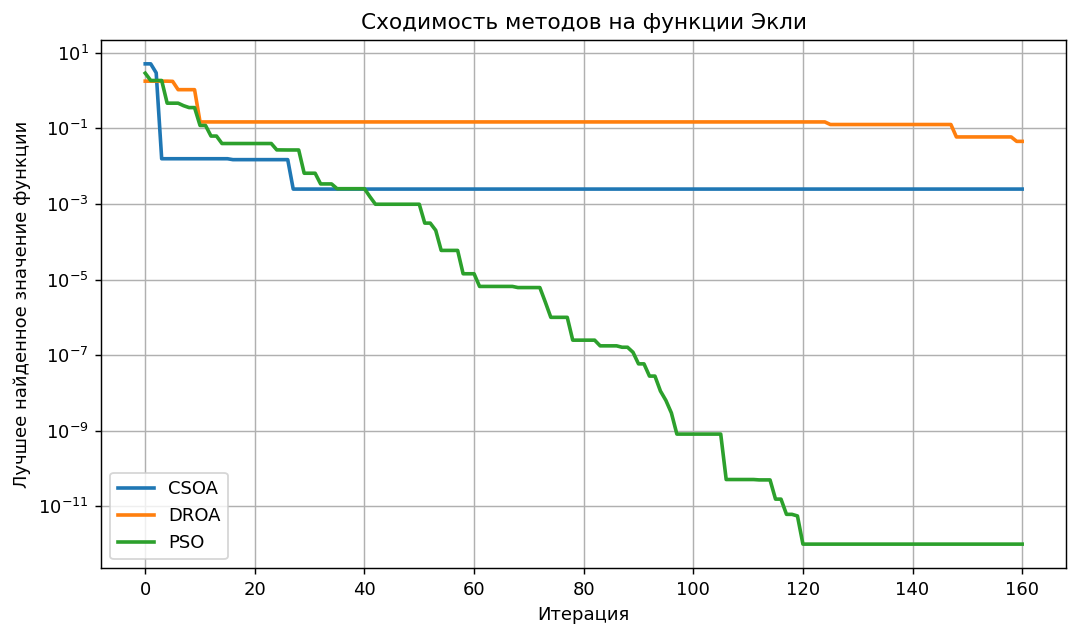

PosixPath('/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)/graphs/convergence_comparison.png')

In [11]:
plt.figure(figsize=(8.4, 5.0))
for item in results:
    history = np.maximum(item["best_history"], 1e-12)
    plt.semilogy(history, linewidth=2, label=item["method"])

plt.xlabel("Итерация")
plt.ylabel("Лучшее найденное значение функции")
plt.title("Сходимость методов на функции Экли")
plt.legend()
plt.tight_layout()
convergence_path = GRAPHS_DIR / "convergence_comparison.png"
plt.savefig(convergence_path)
plt.show()
convergence_path

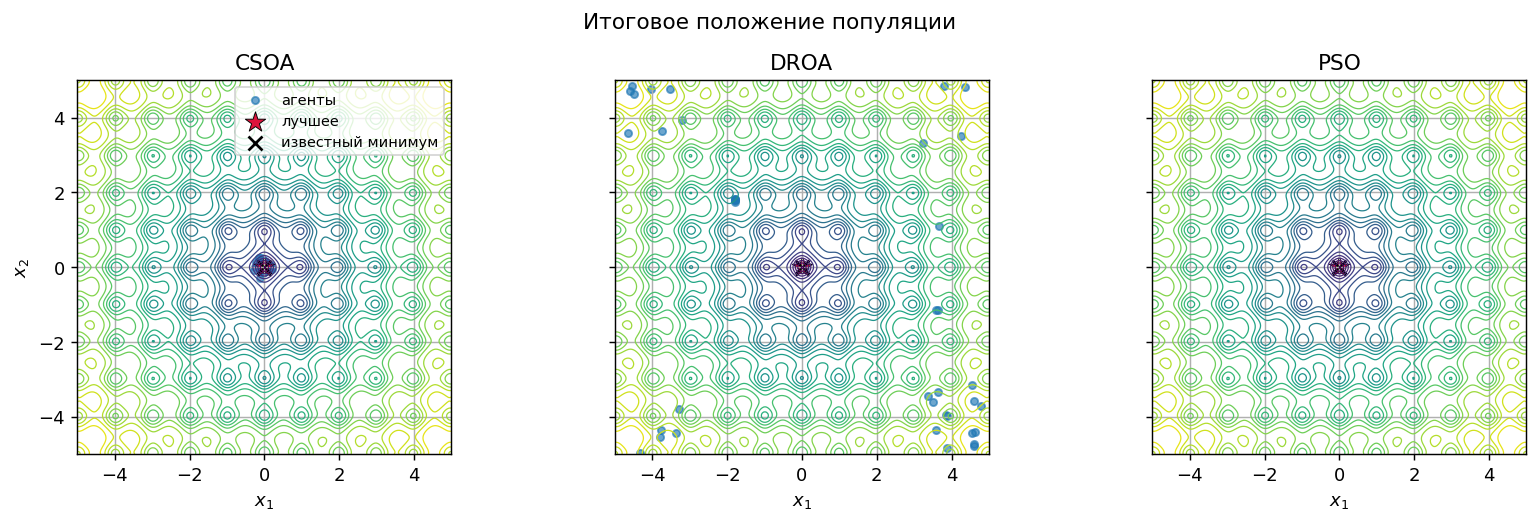

PosixPath('/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)/graphs/final_positions_comparison.png')

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0), sharex=True, sharey=True)

for ax, item in zip(axes, results):
    ax.contour(xx, yy, zz, levels=levels, cmap="viridis", linewidths=0.7)
    final_positions = item["final_positions"]
    ax.scatter(final_positions[:, 0], final_positions[:, 1], s=16, alpha=0.65, label="агенты")
    ax.scatter(
        item["best_position"][0],
        item["best_position"][1],
        marker="*",
        s=140,
        color="crimson",
        edgecolor="black",
        linewidth=0.5,
        label="лучшее",
    )
    ax.scatter(
        GLOBAL_MINIMUM["point"][0],
        GLOBAL_MINIMUM["point"][1],
        marker="x",
        s=60,
        color="black",
        label="известный минимум",
    )
    ax.set_title(item["method"])
    ax.set_xlabel("$x_1$")
    ax.set_aspect("equal", adjustable="box")

axes[0].set_ylabel("$x_2$")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Итоговое положение популяции")
fig.tight_layout()
final_positions_path = GRAPHS_DIR / "final_positions_comparison.png"
fig.savefig(final_positions_path)
plt.show()
final_positions_path

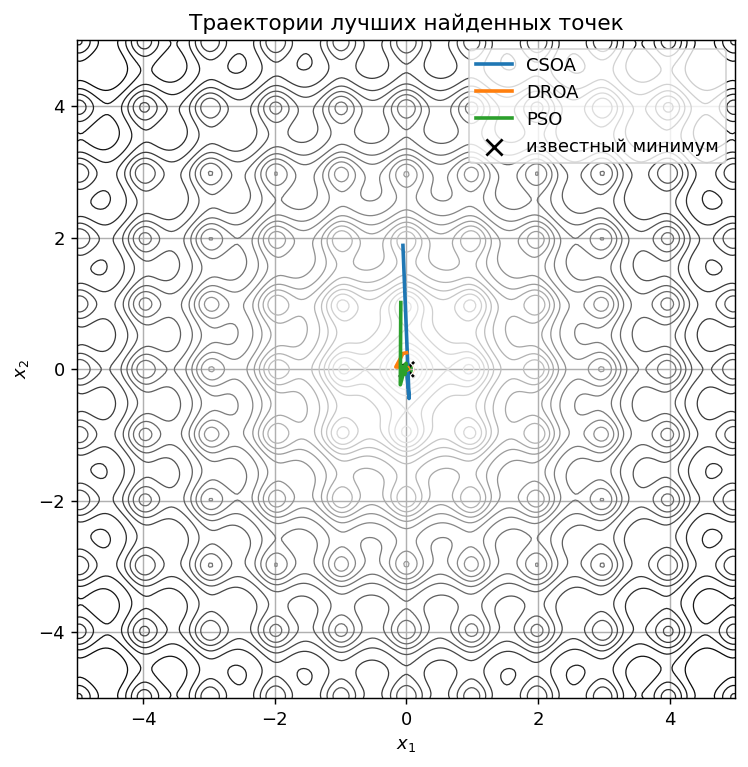

PosixPath('/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)/graphs/best_paths_comparison.png')

In [13]:
plt.figure(figsize=(7.2, 6.0))
plt.contour(xx, yy, zz, levels=levels, cmap="Greys", linewidths=0.7)

for item in results:
    path = item["best_position_history"]
    plt.plot(path[:, 0], path[:, 1], linewidth=2, label=item["method"])
    plt.scatter(path[-1, 0], path[-1, 1], s=45)

plt.scatter(
    GLOBAL_MINIMUM["point"][0],
    GLOBAL_MINIMUM["point"][1],
    marker="x",
    s=80,
    color="black",
    label="известный минимум",
)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Траектории лучших найденных точек")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
best_paths_path = GRAPHS_DIR / "best_paths_comparison.png"
plt.savefig(best_paths_path)
plt.show()
best_paths_path

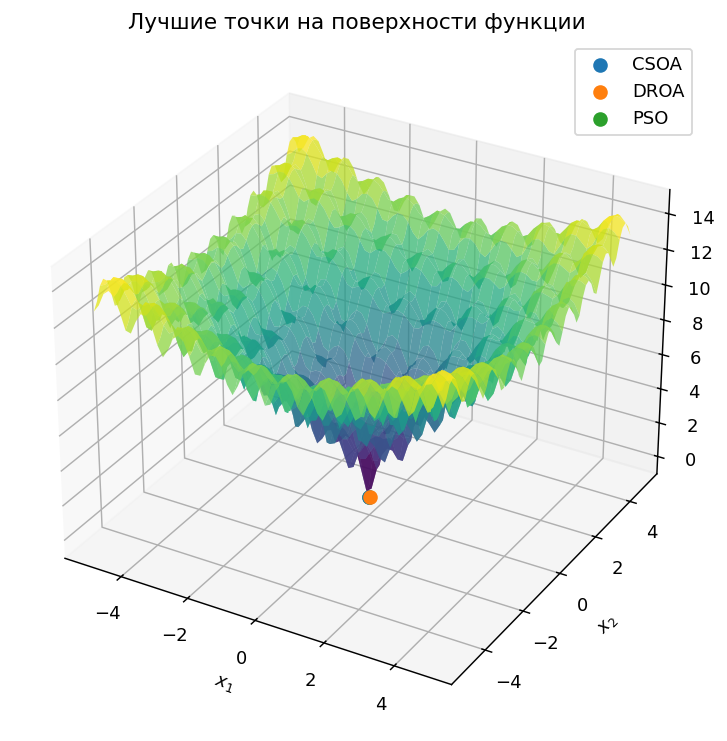

PosixPath('/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)/graphs/surface_best_points.png')

In [14]:
fig = plt.figure(figsize=(8.0, 5.8))
ax = fig.add_subplot(111, projection="3d")
stride = 4
ax.plot_surface(xx[::stride, ::stride], yy[::stride, ::stride], zz[::stride, ::stride], cmap="viridis", alpha=0.75)

for item in results:
    point = item["best_position"]
    ax.scatter(point[0], point[1], item["best_value"], s=50, label=item["method"])

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x)$")
ax.set_title("Лучшие точки на поверхности функции")
ax.legend()
plt.tight_layout()
surface_path = GRAPHS_DIR / "surface_best_points.png"
plt.savefig(surface_path)
plt.show()
surface_path

## Автоматическая генерация отчёта

Ноутбук сохраняет исходник отчёта `report_metaheuristics.tex`. PDF собирается обычным `pdflatex`; готовый файл лежит рядом с ноутбуком.

In [15]:
def latex_number(value, digits=6):
    return f"{float(value):.{digits}f}"


rows_tex = "\n".join(
    (
        f"{row.method} & "
        f"{latex_number(row.best_x)} & "
        f"{latex_number(row.best_y)} & "
        f"{latex_number(row.best_value)} & "
        f"{latex_number(row.distance_to_known_point)} \\\\"
    )
    for row in results_df.itertuples(index=False)
)

params_tex = "\n".join([
    f"Число агентов & {COMMON['population_size']} \\\\",
    f"Число итераций & {COMMON['iterations']} \\\\",
    f"CSOA: SMP & {CSOA_PARAMS['seeking_memory_pool']} \\\\",
    f"CSOA: SRD & {CSOA_PARAMS['seeking_range']} \\\\",
    f"CSOA: MR & {CSOA_PARAMS['tracing_ratio']} \\\\",
    f"DROA: радиус соседства & {DROA_PARAMS['radius_start']}--{DROA_PARAMS['radius_end']} диагонали \\\\",
    f"PSO: $c_1$, $c_2$ & {PSO_PARAMS['cognitive']}; {PSO_PARAMS['social']} \\\\",
])

report_tex = rf"""
\documentclass[12pt,a4paper]{{article}}
\usepackage[T2A]{{fontenc}}
\usepackage[utf8]{{inputenc}}
\usepackage[russian]{{babel}}
\usepackage{{amsmath,amssymb}}
\usepackage{{geometry}}
\usepackage{{graphicx}}
\usepackage{{float}}
\usepackage{{booktabs}}
\geometry{{margin=2.2cm}}

\title{{Сравнение метаэвристических алгоритмов CSOA и DROA}}
\author{{}}
\date{{июнь 2026}}

\begin{{document}}
\maketitle

\section*{{Постановка}}
Требовалось выбрать два метода из CSOA, DROA и TROA, сравнить их на одной функции и добавить PSO для сопоставления. Для сравнения выбраны CSOA и DROA, так как первый метод чередует поиск и преследование, а второй использует взаимодействие агентов через соседей.

В качестве тестовой задачи использована функция Экли:
\[
f(x)=-20\exp\left(-0.2\sqrt{{\frac{{1}}{{n}}\sum_i x_i^2}}\right)
-\exp\left(\frac{{1}}{{n}}\sum_i \cos(2\pi x_i)\right)+20+e,
\]
где $x\in[-5,5]^2$. Известный глобальный минимум равен $f(0,0)=0$.

\section*{{Кратко о методах}}
В CSOA агент находится либо в режиме поиска, либо в режиме преследования. В режиме поиска строится несколько локальных кандидатов; в режиме преследования скорость обновляется в направлении лучшей найденной точки:
\[
v_i^{{t+1}} = v_i^t + c r (x^{{best}} - x_i^t), \qquad x_i^{{t+1}}=x_i^t+v_i^{{t+1}}.
\]

В DROA шаг агента складывается из разделения, выравнивания, сцепления, притяжения к пище и удаления от врага:
\[
\Delta X^{{t+1}} = sS+aA+cC+fF+eE+w\Delta X^t.
\]
В реализации пищей считается лучшая найденная точка, врагом -- худший агент текущей популяции.

PSO добавлен как базовый метод:
\[
v_i^{{t+1}} = wv_i^t+c_1r_1(p_i^{{best}}-x_i^t)+c_2r_2(g^{{best}}-x_i^t).
\]

\section*{{Параметры}}
\begin{{center}}
\begin{{tabular}}{{lr}}
\toprule
Параметр & Значение \\
\midrule
{params_tex}
\bottomrule
\end{{tabular}}
\end{{center}}

\section*{{Результаты}}
\begin{{center}}
\begin{{tabular}}{{lrrrr}}
\toprule
Метод & $x_1$ & $x_2$ & $f(x)$ & расстояние до $(0,0)$ \\
\midrule
{rows_tex}
\bottomrule
\end{{tabular}}
\end{{center}}

Все методы приблизились к известному минимуму. На данной постановке PSO сходится быстрее, CSOA стабильно уточняет решение через локальные пробы, DROA сильнее зависит от радиуса соседства и веса притяжения к лучшей точке.

\section*{{Графики}}
\begin{{figure}}[H]
\centering
\includegraphics[width=0.88\textwidth]{{graphs/convergence_comparison.png}}
\caption{{Лучшее найденное значение функции от номера итерации.}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.96\textwidth]{{graphs/final_positions_comparison.png}}
\caption{{Итоговое положение популяций на линиях уровня функции.}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.76\textwidth]{{graphs/best_paths_comparison.png}}
\caption{{Траектории лучших найденных точек.}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.78\textwidth]{{graphs/surface_best_points.png}}
\caption{{Лучшие точки на поверхности функции.}}
\end{{figure}}

\section*{{Вывод}}
Для выбранной функции все три алгоритма нашли точки около глобального минимума. PSO оказался самым быстрым на гладкой двумерной задаче, но CSOA и DROA также дают рабочую схему глобального поиска. Код в ноутбуке позволяет заменить функцию и параметры без изменения структуры эксперимента.

\end{{document}}
"""

report_path = TASK_DIR / "report_metaheuristics.tex"
report_path.write_text(report_tex.strip() + "\n", encoding="utf-8")
print(report_path)

/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Сравнение метаэвристических алгоритмов (CSOA, DROA, TROA)/report_metaheuristics.tex
